In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv

In [ ]:
data = pd.read_csv(assets/Train.csv)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [5]:
data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [12]:
# range_val = np.ptp(data['Customer_rating'])
# print(range_val)

data['Customer_rating'].index

RangeIndex(start=0, stop=10999, step=1)

                           ID  Customer_care_calls  Customer_rating  \
ID                   1.000000             0.188998        -0.005722   
Customer_care_calls  0.188998             1.000000         0.012209   
Customer_rating     -0.005722             0.012209         1.000000   
Cost_of_the_Product  0.196791             0.323182         0.009270   
Prior_purchases      0.145369             0.180771         0.013179   
Discount_offered    -0.598278            -0.130750        -0.003124   
Weight_in_gms        0.278312            -0.276615        -0.001897   
Reached.on.Time_Y.N -0.411822            -0.067126         0.013119   

                     Cost_of_the_Product  Prior_purchases  Discount_offered  \
ID                              0.196791         0.145369         -0.598278   
Customer_care_calls             0.323182         0.180771         -0.130750   
Customer_rating                 0.009270         0.013179         -0.003124   
Cost_of_the_Product             1.000000    

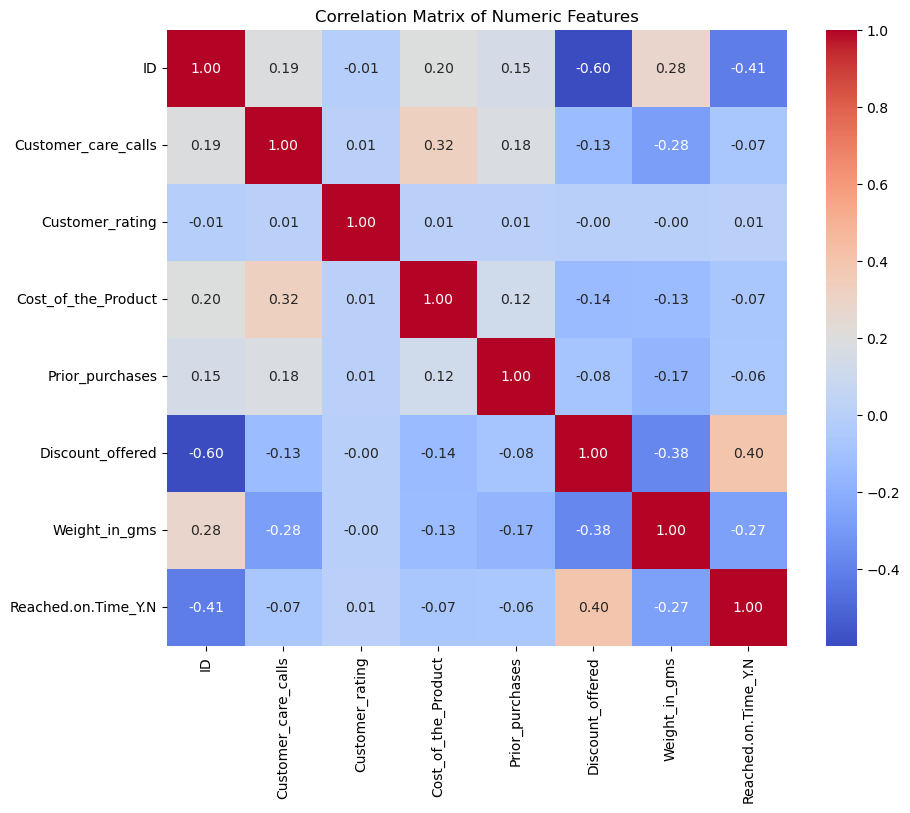

In [13]:
# Select only numeric columns
numeric_cols = data.select_dtypes(include=['int64']).columns
numeric_df = data[numeric_cols]

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Print correlation matrix
print(corr_matrix)

# Optional: visualize with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

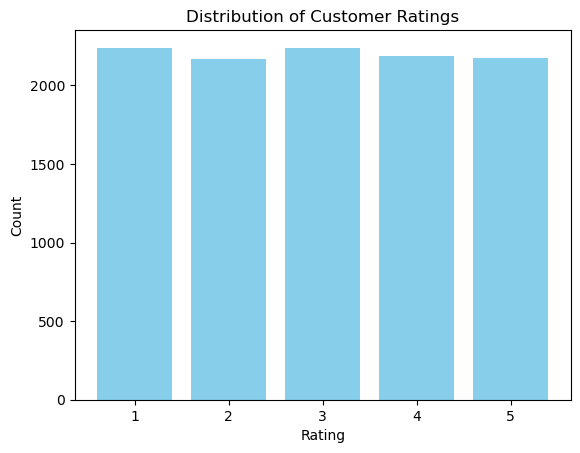

In [24]:
import matplotlib.pyplot as plt

target = data['Customer_rating']
# Count occurrences of each rating
target_counts = data['Customer_rating'].value_counts().sort_index()

# Plot
plt.bar(target_counts.index, target_counts.values, color='skyblue')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Customer Ratings')
plt.xticks([1, 2, 3, 4, 5])
plt.show()

/var/folders/7s/szfb96hs5db4l9fb_5vdhxyh0000gn/T/ipykernel_47952/1449908128.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Customer_rating', y='Cost_of_the_Product', data=data, palette='pastel')


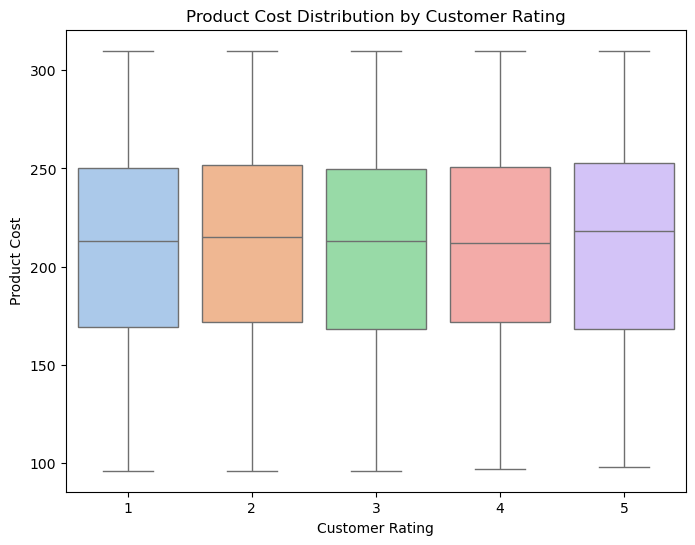

In [31]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x='Customer_rating', y='Cost_of_the_Product', data=data, palette='pastel')
plt.xlabel('Customer Rating')
plt.ylabel('Product Cost')
plt.title('Product Cost Distribution by Customer Rating')
plt.show()

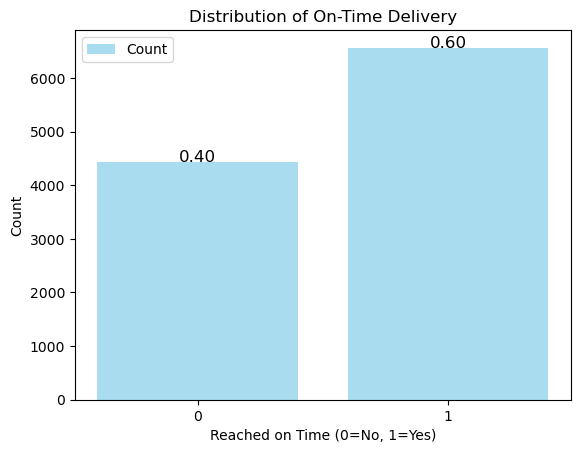

In [23]:
import matplotlib.pyplot as plt

# Compute probabilities
target_prob = target_counts / target_counts.sum()

# Plot counts
plt.bar(target_counts.index, target_counts.values, color='skyblue', alpha=0.7, label='Count')

# Overlay probabilities as text above bars
for i, (count, prob) in enumerate(zip(target_counts.values, target_prob.values)):
    plt.text(i, count + 0.1, f"{prob:.2f}", ha='center', fontsize=12)

plt.xlabel('Reached on Time (0=No, 1=Yes)')
plt.ylabel('Count')
plt.title('Distribution of On-Time Delivery')
plt.xticks([0, 1])
plt.legend()
plt.show()
